# Credit Card Fraud Detection — Supervised Learning


The aim of this project is to build a fraud classifier on a strongly imbalanced credit-card dataset and then choose a probability threshold that makes more sense for the business than the default 0.5 cutoff.

The full dataset is not used directly for model fitting. I first take the required 50,000-row stratified sample (random_state=42), keeping the fraud ratio close to the original data. The test set is kept untouched after the train/test split.

## Step 1 — Problem framing and theory notes

### Why accuracy is not useful here
Fraud is rare in this dataset (about 0.17%). A model that predicts every transaction as legitimate would still get about **99.83% accuracy**, but it would catch **zero fraud cases**. For the Fraud class, both precision and recall are 0 in that situation (precision is technically undefined when there are no positive predictions, but in a practical report it is treated as 0).

### Precision–Recall tradeoff
- **Precision** = among transactions flagged as fraud, how many are actually fraud.
- **Recall** = among actual fraud transactions, how many are caught.

| Actual / Predicted | Legit | Fraud |
|---|---:|---:|
| Legit | TN | FP |
| Fraud | FN | TP |

Lowering a fraud threshold from 0.5 to 0.2 usually catches more fraud, so recall rises. The tradeoff is that more legitimate transactions may also be flagged, so precision can fall.

### Three imbalance strategies
**Random undersampling:** reduce the number of legitimate transactions in the training set. It is simple and fast, but it throws away information.

**SMOTE:** create synthetic minority-class training examples. It keeps more majority information than undersampling, but synthetic points are not always perfect representations of real fraud.

**`class_weight='balanced'`:** increase the penalty for mistakes on the minority class. It does not change the training rows, so no information is discarded or synthetically created. The downside is that the model may become more willing to flag legitimate transactions.

### Why PR-AUC
PR-AUC focuses directly on the precision/recall behaviour of the minority class. With extreme imbalance, it is more informative for this task than ROC-AUC because a high ROC-AUC can still hide weak fraud precision.

### Business cost of errors
A **false negative** means real fraud is missed, so the company can lose money and may have to deal with a customer dispute. A **false positive** means a legitimate transaction is stopped or reviewed, which costs analyst time and can create unnecessary customer friction. In this exam, the false-negative cost is set much higher than the investigation cost.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, precision_recall_curve,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier
import joblib

## Step 2 — Dataset loading and EDA

In [2]:
df = pd.read_csv("creditcard.csv")

print("Full dataset shape:", df.shape)
print("\nClass distribution:")
print(df["Class"].value_counts())
print("\nClass distribution (proportion):")
print(df["Class"].value_counts(normalize=True).rename("proportion"))

Full dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution (proportion):
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [ ]:

data, _ = train_test_split(
    df,
    train_size=50000,
    stratify=df["Class"],
    random_state=42
)

print("Sample shape:", data.shape)
print("\nSample class counts:")
print(data["Class"].value_counts())
print("\nSample class distribution:")
print(data["Class"].value_counts(normalize=True).rename("proportion"))

print("\nDescription of Time and Amount:")
display(data[["Time", "Amount"]].describe())

Sample shape: (50000, 31)

Sample class counts:
Class
0    49914
1       86
Name: count, dtype: int64

Sample class distribution:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64

Description of Time and Amount:


,Time,Amount
count,50000.00000,50000.000000
mean,94977.93554,86.942063
std,47475.50731,226.984602
min,0.00000,0.000000
25%,54423.50000,5.850000
50%,84852.00000,22.000000
75%,139392.25000,76.275000
max,172787.00000,8360.000000


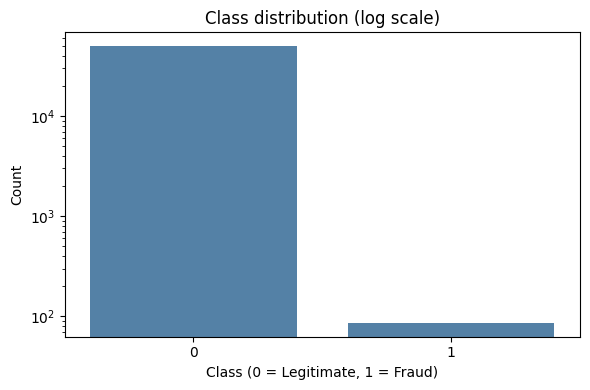

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="Class", color="steelblue")
plt.yscale("log")
plt.title("Class distribution (log scale)")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

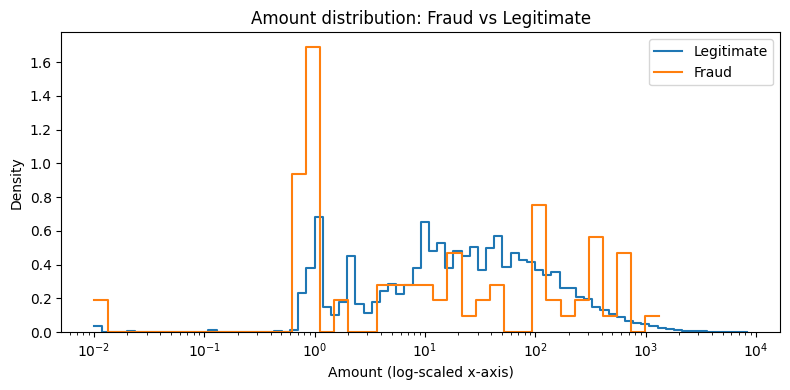

Median Amount - Legitimate: 22.0
Median Amount - Fraud: 7.355


In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(data=data[data["Class"] == 0], x="Amount", bins=80, stat="density",
             element="step", fill=False, label="Legitimate", color="tab:blue", log_scale=(True, False))
sns.histplot(data=data[data["Class"] == 1], x="Amount", bins=40, stat="density",
             element="step", fill=False, label="Fraud", color="tab:orange")
plt.title("Amount distribution: Fraud vs Legitimate")
plt.xlabel("Amount (log-scaled x-axis)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print("Median Amount - Legitimate:", data.loc[data.Class == 0, "Amount"].median())
print("Median Amount - Fraud:", data.loc[data.Class == 1, "Amount"].median())

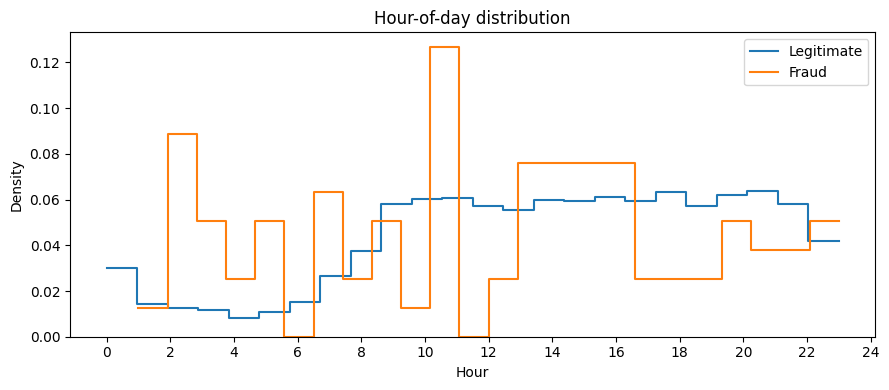

Class
0    84882.0
1    67122.0
Name: median Time, dtype: float64


In [6]:
data_plot = data.copy()
data_plot["Hour"] = (data_plot["Time"] % 86400) // 3600

plt.figure(figsize=(9, 4))
sns.histplot(data=data_plot[data_plot["Class"] == 0], x="Hour", bins=24,
             stat="density", element="step", fill=False, label="Legitimate", color="tab:blue")
sns.histplot(data=data_plot[data_plot["Class"] == 1], x="Hour", bins=24,
             stat="density", element="step", fill=False, label="Fraud", color="tab:orange")
plt.xticks(range(0, 25, 2))
plt.title("Hour-of-day distribution")
plt.xlabel("Hour")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print(data.groupby("Class")["Time"].median().rename("median Time"))

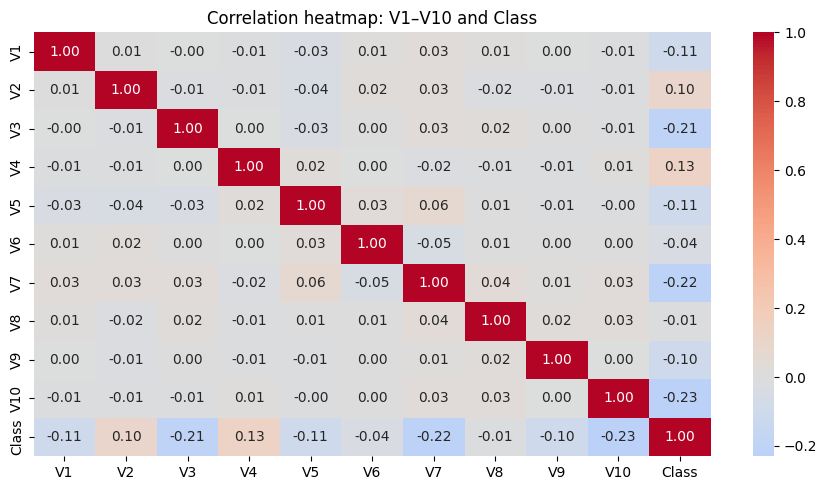

V-feature correlations with Class:


V10   -0.229868
V7    -0.216016
V3    -0.205368
V5    -0.107581
V1    -0.107532
V9    -0.104933
V6    -0.036334
V8    -0.009454
V2     0.099175
V4     0.130889
Name: Class, dtype: float64

In [7]:
corr = data[[f"V{i}" for i in range(1, 11)] + ["Class"]].corr()

plt.figure(figsize=(9, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap: V1–V10 and Class")
plt.tight_layout()
plt.show()

print("V-feature correlations with Class:")
display(corr["Class"].drop("Class").sort_values())

### EDA observations

The sample keeps the expected severe imbalance. Fraud transactions have a much lower median Amount than legitimate transactions in this sample, so the small-transaction pattern is visible. The Time plot shows that fraud is not distributed exactly like legitimate activity, although there is considerable overlap. Among V1–V10, V10 and V7 have the strongest negative correlations with Class, while V4 has the strongest positive correlation in this small correlation view.

## Step 3 — Feature engineering, scaling and train/test split

In [8]:
model_data = data.copy()

model_data["Amount_log"] = np.log1p(model_data["Amount"])
model_data["Hour"] = (model_data["Time"] % 86400) // 3600
model_data = model_data.drop(columns=["Time", "Amount"])

X = model_data.drop(columns=["Class"])
y = model_data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
scale_cols = ["Amount_log", "Hour"]

X_train = X_train.copy()
X_test = X_test.copy()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class counts:")
print(y_train.value_counts())
print("\nTest class counts:")
print(y_test.value_counts())
print("\nTrain proportions:")
print(y_train.value_counts(normalize=True))
print("\nTest proportions:")
print(y_test.value_counts(normalize=True))

Train shape: (40000, 30)
Test shape: (10000, 30)

Train class counts:
Class
0    39931
1       69
Name: count, dtype: int64

Test class counts:
Class
0    9983
1      17
Name: count, dtype: int64

Train proportions:
Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64

Test proportions:
Class
0    0.9983
1    0.0017
Name: proportion, dtype: float64


In [9]:
smote = SMOTE(random_state=42, sampling_strategy=0.1)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

undersampler = RandomUnderSampler(random_state=42, sampling_strategy=0.1)
X_under, y_under = undersampler.fit_resample(X_train, y_train)

print("Original training counts:", y_train.value_counts().to_dict())
print("SMOTE training counts:", pd.Series(y_smote).value_counts().to_dict())
print("Undersampled training counts:", pd.Series(y_under).value_counts().to_dict())

Original training counts: {0: 39931, 1: 69}
SMOTE training counts: {0: 39931, 1: 3993}
Undersampled training counts: {0: 690, 1: 69}


## Step 4 — Logistic Regression and Random Forest

In [10]:
def get_metrics(model, X_eval=X_test, y_eval=y_test, threshold=0.5):
    prob = model.predict_proba(X_eval)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "F1": f1_score(y_eval, pred, zero_division=0),
        "PR-AUC": average_precision_score(y_eval, prob)
    }, prob

lr_original = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=42
)
lr_original.fit(X_train, y_train)

lr_smote = LogisticRegression(
    class_weight=None, max_iter=1000, random_state=42
)
lr_smote.fit(X_smote, y_smote)

lr_under = LogisticRegression(
    class_weight=None, max_iter=1000, random_state=42
)
lr_under.fit(X_under, y_under)

lr_results = []
for name, model in [
    ("LR - Original", lr_original),
    ("LR - SMOTE", lr_smote),
    ("LR - Undersampled", lr_under)
]:
    m, _ = get_metrics(model)
    lr_results.append({"Model": name, **m})

lr_table = pd.DataFrame(lr_results)
display(lr_table.round(4))

,Model,Precision,Recall,F1,PR-AUC
0,LR - Original,0.0649,1.0000,0.1219,0.7814
1,LR - SMOTE,0.3091,1.0000,0.4722,0.8144
2,LR - Undersampled,0.2286,0.9412,0.3678,0.8093


In [11]:
# SMOTE gave the strongest PR-AUC among the three Logistic Regression variants.
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_smote, y_smote)

rf_metrics, rf_prob = get_metrics(rf)
display(pd.DataFrame([{"Model": "Random Forest (SMOTE)", **rf_metrics}]).round(4))

,Model,Precision,Recall,F1,PR-AUC
0,Random Forest (SMOTE),0.9333,0.8235,0.875,0.8904


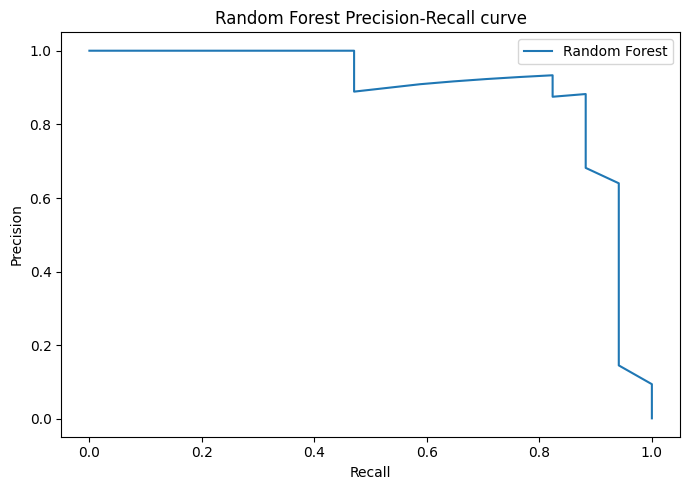

In [12]:
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall_rf, precision_rf, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall curve")
plt.legend()
plt.tight_layout()
plt.show()

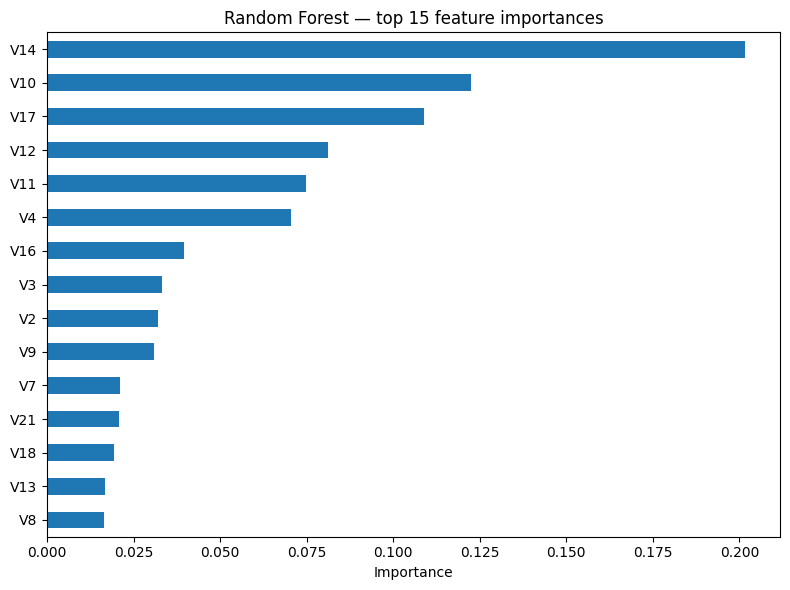

,Importance
V14,0.20163
V10,0.12243
V17,0.10891
V12,0.08120
V11,0.07483
V4,0.07046
V16,0.03972
V3,0.03314
V2,0.03219
V9,0.03101


In [13]:
fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
fi.sort_values().plot(kind="barh")
plt.title("Random Forest — top 15 feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(fi.to_frame("Importance").round(5))

## Step 5 — XGBoost baseline, tuning and threshold optimisation

In [14]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print("scale_pos_weight:", round(ratio, 4))

xgb_baseline = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist"
)
xgb_baseline.fit(X_train, y_train)

xgb_base_metrics, xgb_base_prob = get_metrics(xgb_baseline)
display(pd.DataFrame([{"Model": "XGBoost Baseline", **xgb_base_metrics}]).round(4))

scale_pos_weight: 578.7101


,Model,Precision,Recall,F1,PR-AUC
0,XGBoost Baseline,1.0,0.8235,0.9032,0.8996


In [15]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

xgb_for_search = XGBClassifier(
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist"
)

search = RandomizedSearchCV(
    xgb_for_search,
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring="average_precision",
    random_state=42,
    n_jobs=1
)
search.fit(X_train, y_train)

xgb_tuned = search.best_estimator_

print("Best parameters:")
print(search.best_params_)
print("\nBest CV PR-AUC:", round(search.best_score_, 6))

xgb_tuned_metrics, xgb_tuned_prob = get_metrics(xgb_tuned)
display(pd.DataFrame([
    {"Model": "XGBoost Baseline", **xgb_base_metrics},
    {"Model": "XGBoost Tuned", **xgb_tuned_metrics}
]).round(4))

Best parameters:
{'subsample': 0.6, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best CV PR-AUC: 0.801337


,Model,Precision,Recall,F1,PR-AUC
0,XGBoost Baseline,1.0000,0.8235,0.9032,0.8996
1,XGBoost Tuned,0.9286,0.7647,0.8387,0.9133


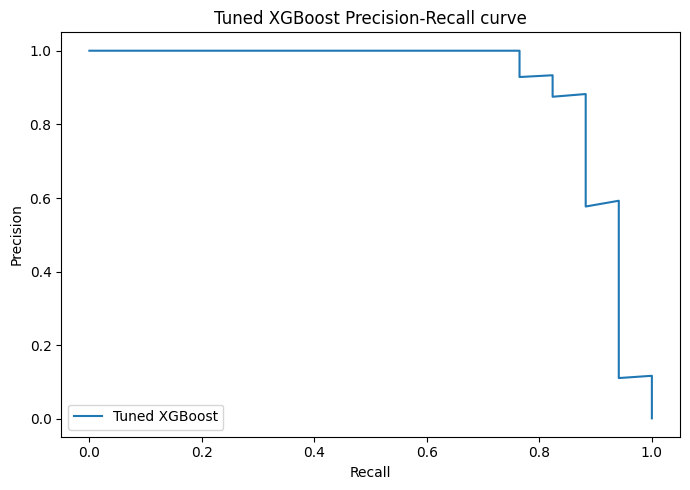

In [16]:
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(
    y_test, xgb_tuned_prob
)

plt.figure(figsize=(7, 5))
plt.plot(recall_xgb, precision_xgb, label="Tuned XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Tuned XGBoost Precision-Recall curve")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
f1_values = 2 * precision_xgb[:-1] * recall_xgb[:-1] / (
    precision_xgb[:-1] + recall_xgb[:-1] + 1e-12
)
f1_idx = np.argmax(f1_values)
f1_threshold = float(thresholds_xgb[f1_idx])
valid = np.where(recall_xgb[:-1] >= 0.90)[0]
recall90_idx = valid[np.argmax(precision_xgb[:-1][valid])]
recall90_threshold = float(thresholds_xgb[recall90_idx])

print("F1-optimal threshold:", round(f1_threshold, 6))
print("Recall >= 0.90 threshold:", round(recall90_threshold, 6))

threshold_metrics = []
for label, th in [
    ("Default 0.5", 0.5),
    ("F1-optimal", f1_threshold),
    ("Recall >= 0.90", recall90_threshold)
]:
    pred = (xgb_tuned_prob >= th).astype(int)
    threshold_metrics.append({
        "Threshold variant": label,
        "Threshold": th,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "PR-AUC": average_precision_score(y_test, xgb_tuned_prob)
    })

display(pd.DataFrame(threshold_metrics).round(4))

F1-optimal threshold: 0.393029
Recall >= 0.90 threshold: 0.014813


,Threshold variant,Threshold,Precision,Recall,F1,PR-AUC
0,Default 0.5,0.5000,0.9286,0.7647,0.8387,0.9133
1,F1-optimal,0.3930,0.8824,0.8824,0.8824,0.9133
2,Recall >= 0.90,0.0148,0.5926,0.9412,0.7273,0.9133


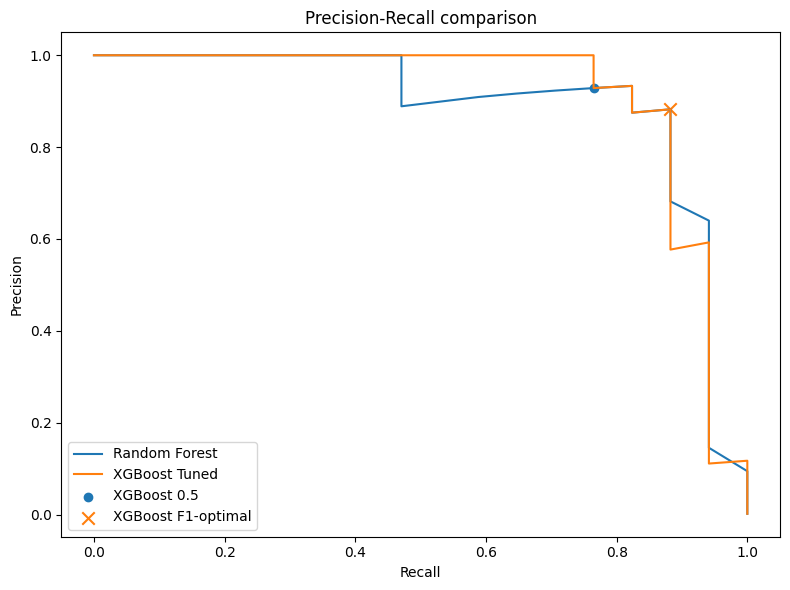

In [18]:
plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, label="Random Forest")
plt.plot(recall_xgb, precision_xgb, label="XGBoost Tuned")
plt.scatter(
    [recall_score(y_test, (xgb_tuned_prob >= 0.5).astype(int))],
    [precision_score(y_test, (xgb_tuned_prob >= 0.5).astype(int), zero_division=0)],
    marker="o", label="XGBoost 0.5"
)
plt.scatter(
    [recall_xgb[f1_idx]], [precision_xgb[f1_idx]],
    marker="x", s=80, label="XGBoost F1-optimal"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall comparison")
plt.legend()
plt.tight_layout()
plt.show()

## Step 6 — Final model comparison and recommendation

In [19]:
def row_for_model(name, model, threshold=0.5):
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {
        "Model": name,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "PR-AUC": average_precision_score(y_test, prob),
        "Threshold": threshold
    }

comparison = pd.DataFrame([
    row_for_model("Logistic Regression (SMOTE)", lr_smote, 0.5),
    row_for_model("Random Forest (SMOTE)", rf, 0.5),
    row_for_model("XGBoost Baseline", xgb_baseline, 0.5),
    row_for_model("XGBoost Tuned", xgb_tuned, 0.5),
    row_for_model("XGBoost Tuned (F1-optimal)", xgb_tuned, f1_threshold),
    row_for_model("XGBoost Tuned (Recall >= 0.90)", xgb_tuned, recall90_threshold),
])

display(comparison.round(4))

,Model,Precision,Recall,F1,PR-AUC,Threshold
0,Logistic Regression (SMOTE),0.3091,1.0000,0.4722,0.8144,0.5000
1,Random Forest (SMOTE),0.9333,0.8235,0.8750,0.8904,0.5000
2,XGBoost Baseline,1.0000,0.8235,0.9032,0.8996,0.5000
3,XGBoost Tuned,0.9286,0.7647,0.8387,0.9133,0.5000
4,XGBoost Tuned (F1-optimal),0.8824,0.8824,0.8824,0.9133,0.3930
5,XGBoost Tuned (Recall >= 0.90),0.5926,0.9412,0.7273,0.9133,0.0148


### Recommendation

For deployment, I would use the **tuned XGBoost model with the F1-optimal threshold** as the main operating point. On the held-out test set it improves the fraud-class F1 from the default 0.5 setting while keeping strong precision and recall, and its PR-AUC is the highest among the main tested models. The threshold is about **0.393**, rather than the default 0.5, which catches more of the fraud cases in this test split. A risk team that wants even higher recall can move to the lower threshold found for Recall ≥ 0.90, accepting more false alerts. In production, the final threshold should be reviewed using actual investigation capacity and fraud-loss estimates rather than selected only from an ML metric.

## Step 7 — Business simulation and cost-benefit analysis

In [20]:
def cost_benefit(threshold):
    pred = (xgb_tuned_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    money_saved = tp * 4500
    investigation_cost = (tp + fp) * 150
    money_lost = fn * 4500
    net_benefit = money_saved - investigation_cost

    return {
        "Threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Money Saved": money_saved,
        "Investigation Cost": investigation_cost,
        "Money Lost": money_lost,
        "Net Benefit": net_benefit
    }

cost_table = pd.DataFrame([
    cost_benefit(0.1),
    cost_benefit(0.2),
    cost_benefit(0.3),
    cost_benefit(0.5),
    cost_benefit(f1_threshold)
])

display(cost_table.round(2))
print(
    "\nHighest net benefit threshold:",
    cost_table.loc[cost_table["Net Benefit"].idxmax(), "Threshold"]
)

,Threshold,TP,FP,FN,Money Saved,Investigation Cost,Money Lost,Net Benefit
0,0.10,15,4,2,67500,2850,9000,64650
1,0.20,15,2,2,67500,2550,9000,64950
2,0.30,15,2,2,67500,2550,9000,64950
3,0.50,13,1,4,58500,2100,18000,56400
4,0.39,15,2,2,67500,2550,9000,64950



Highest net benefit threshold: 0.2


### business interpretation

At a threshold of 0.5 the model misses more fraud, which reduces the amount of money recovered. Moving the threshold lower catches more fraud but also increases the number of transactions sent for review. In this test sample, the highest net benefit is obtained around the same lower-threshold operating region as the F1-optimal setting, but the exact choice should still be validated on a larger live-style sample.

## Step 8 — Save the final pipeline

In [ ]:
from sklearn.base import clone

X_train_raw = model_data.drop(columns=["Class"]).loc[X_train.index].copy()

prep = ColumnTransformer(
    transformers=[
        ("scale_amount_hour", StandardScaler(), ["Amount_log", "Hour"])
    ],
    remainder="passthrough"
)

final_model = clone(xgb_tuned)

final_pipeline = Pipeline([
    ("preprocess", prep),
    ("model", final_model)
])

final_pipeline.fit(X_train_raw, y_train)

final_pipeline.threshold_ = f1_threshold

joblib.dump(final_pipeline, "fraud_detection_model.pkl")
print("Saved: fraud_detection_model.pkl")

Saved: fraud_detection_model.pkl


In [22]:
loaded_pipeline = joblib.load("fraud_detection_model.pkl")

demo_raw = model_data.drop(columns=["Class"]).loc[X_test.index].head(10).copy()
demo_prob = loaded_pipeline.predict_proba(demo_raw)[:, 1]
demo_label = (demo_prob >= loaded_pipeline.threshold_).astype(int)

demo_output = pd.DataFrame({
    "Predicted probability": demo_prob,
    "Final label": demo_label
})
display(demo_output.round(4))

,Predicted probability,Final label
0,0.0000,0
1,0.0000,0
2,0.0000,0
3,0.0003,0
4,0.0000,0
5,0.0006,0
6,0.0000,0
7,0.0000,0
8,0.0000,0
9,0.0000,0


## Final observations

In [23]:
print("Sample fraud ratio:", round(data["Class"].mean(), 5))
print("Best LR PR-AUC:", round(lr_table["PR-AUC"].max(), 4))
print("Random Forest PR-AUC:", round(rf_metrics["PR-AUC"], 4))
print("XGBoost baseline PR-AUC:", round(xgb_base_metrics["PR-AUC"], 4))
print("XGBoost tuned PR-AUC:", round(xgb_tuned_metrics["PR-AUC"], 4))
print("F1-optimal threshold:", round(f1_threshold, 6))
print("Recall >= 0.90 threshold:", round(recall90_threshold, 6))
print("Best business net benefit:", int(cost_table["Net Benefit"].max()))

Sample fraud ratio: 0.00172
Best LR PR-AUC: 0.8144
Random Forest PR-AUC: 0.8904
XGBoost baseline PR-AUC: 0.8996
XGBoost tuned PR-AUC: 0.9133
F1-optimal threshold: 0.393029
Recall >= 0.90 threshold: 0.014813
Best business net benefit: 64950
